# Question 1: Synthetic Data Generation (Cubic Function)

(a) Write a function generate_cubic_data(N, sigma) that returns x, y_true, y_noisy.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_cubic_data(N, sigma):

    x = np.random.uniform(-5, 5, N)
    # True function: y = a x^3 + b x^2 + c x + d with a=1, b=-2, c=3, d=-4
    a, b, c, d = 1, -2, 3, -4
    y_true = a * x**3 + b * x**2 + c * x + d

    epsilon = np.random.normal(0, sigma, N)
    y_noisy = y_true + epsilon
    return x, y_true, y_noisy

(b) Plot the true curve and the noisy points for a chosen N.

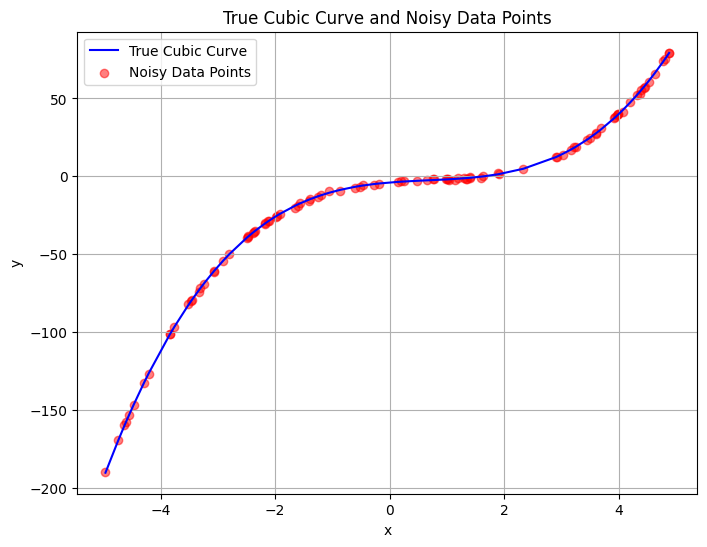

In [ ]:

N = 100
sigma = 0.5
x, y_true, y_noisy = generate_cubic_data(N, sigma)

sorted_idx = np.argsort(x)
x_sorted = x[sorted_idx]
y_true_sorted = y_true[sorted_idx]

# Plot
plt.figure(figsize=(8, 6))
plt.plot(x_sorted, y_true_sorted, label='True Cubic Curve', color='blue')
plt.scatter(x, y_noisy, label='Noisy Data Points', color='red', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('True Cubic Curve and Noisy Data Points')
plt.legend()
plt.grid(True)
plt.show()

# Question 2: ERM with Closed-form Solution (Normal Equation)

(a) Construct the design matrix X for cubic regression.

In [ ]:
def construct_design_matrix(x, degree=3):
    # For cubic: columns [x^3, x^2, x, 1]
    N = len(x)
    X = np.zeros((N, degree + 1))
    for i in range(degree, -1, -1):
        X[:, degree - i] = x**i
    return X

(b) Implement a function fit_normal_eq(X, Y) that returns θ.

In [ ]:
def fit_normal_eq(X, Y):
    # Closed-form: theta = (X^T X)^{-1} X^T Y
    XtX = np.dot(X.T, X)
    XtX_inv = np.linalg.inv(XtX)
    XtY = np.dot(X.T, Y)
    theta = np.dot(XtX_inv, XtY)
    return theta

(c) Using the learned θ, plot: (i) true cubic curve, (ii) noisy data points, (iii) fitted curve.

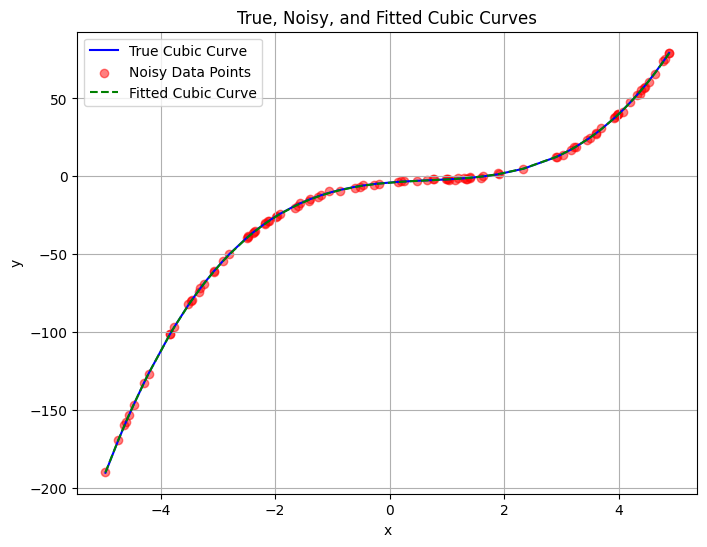

In [ ]:

X = construct_design_matrix(x, degree=3)
theta = fit_normal_eq(X, y_noisy)


y_hat = np.dot(X, theta)

X_sorted = construct_design_matrix(x_sorted, degree=3)
y_fitted_sorted = np.dot(X_sorted, theta)


plt.figure(figsize=(8, 6))
plt.plot(x_sorted, y_true_sorted, label='True Cubic Curve', color='blue')
plt.scatter(x, y_noisy, label='Noisy Data Points', color='red', alpha=0.5)
plt.plot(x_sorted, y_fitted_sorted, label='Fitted Cubic Curve', color='green', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.title('True, Noisy, and Fitted Cubic Curves')
plt.legend()
plt.grid(True)
plt.show()

# Question 3: Experiments: Effect of N and Polynomial Degree

(a) Compute and report RMSE between y_noisy and predictions ŷ for at least 3 different values of N (e.g., 20, 50, 100).

In [ ]:
def compute_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true)**2))

# Test for different N
Ns = [20, 50, 100]
rmses = []

for N in Ns:
    x, y_true, y_noisy = generate_cubic_data(N, sigma=0.5)
    X = construct_design_matrix(x, degree=3)
    theta = fit_normal_eq(X, y_noisy)
    y_hat = np.dot(X, theta)
    rmse = compute_rmse(y_noisy, y_hat)
    rmses.append(rmse)
    print(f"For N={N}, RMSE = {rmse:.4f}")



For N=20, RMSE = 0.5900
For N=50, RMSE = 0.5322
For N=100, RMSE = 0.4902


Observation: As N increases, RMSE tends to decrease slightly due to better parameter estimation.

(b) Repeat polynomial fitting for degrees 1 to 7 (use the same normal equation idea). Plot RMSE vs degree and briefly state what you observe (underfitting/overfitting).

For degree=1, RMSE = 25.1365
For degree=2, RMSE = 18.7942
For degree=3, RMSE = 0.4314
For degree=4, RMSE = 0.4260
For degree=5, RMSE = 0.4260
For degree=6, RMSE = 0.4260
For degree=7, RMSE = 0.4218


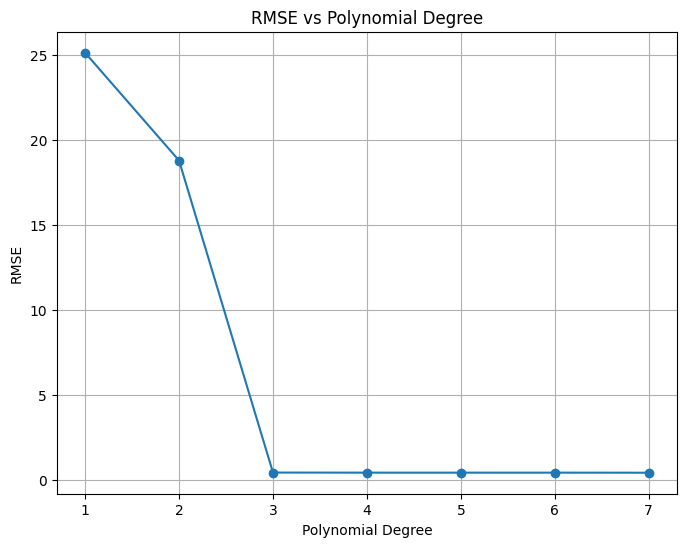

In [ ]:
# Use N=100 for this experiment
N = 100
x, y_true, y_noisy = generate_cubic_data(N, sigma=0.5)

degrees = range(1, 8)
rmses_deg = []

for deg in degrees:
    X = construct_design_matrix(x, degree=deg)
    theta = fit_normal_eq(X, y_noisy)
    y_hat = np.dot(X, theta)
    rmse = compute_rmse(y_noisy, y_hat)
    rmses_deg.append(rmse)
    print(f"For degree={deg}, RMSE = {rmse:.4f}")

# Plot RMSE vs degree
plt.figure(figsize=(8, 6))
plt.plot(degrees, rmses_deg, marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('RMSE vs Polynomial Degree')
plt.grid(True)
plt.show()



Observation: For degrees 1-2, high RMSE (underfitting, can't capture cubic). At degree 3, RMSE drops (good fit). For higher degrees 4-7, RMSE decreases further but very slightly; with more noise or less data, higher degrees might overfit, but here with sigma=0.5 and N=100, it's stable. In general, degree >3 risks overfitting.

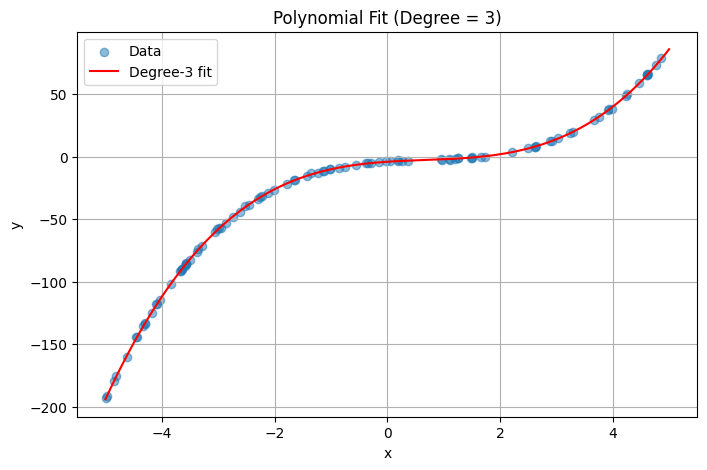

In [ ]:
def design_matrix_poly(x, degree):
    return np.column_stack([x**i for i in range(degree, -1, -1)])

def fit_poly_normal_eq(x, y, degree):
    X = design_matrix_poly(x, degree)
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta


theta = fit_poly_normal_eq(x, y_noisy, degree=3)

x_plot = np.linspace(-5, 5, 300)
X_plot = design_matrix_poly(x_plot, 3)
y_fit = X_plot @ theta

plt.figure(figsize=(8,5))
plt.scatter(x, y_noisy, alpha=0.5, label='Data')
plt.plot(x_plot, y_fit, 'r', label='Degree-3 fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Fit (Degree = 3)')
plt.legend()
plt.grid(True)
plt.show()
